# Vježbe 9 — Aktivacijske funkcije · Dropout · Batch Normalization
**Predmet:** Rudarenje podataka — I. godina — II ciklus — Softversko inženjerstvo  
**Asistent:** ass. mr. Narcisa Hadžajlić  
**Datum:** 20.4.2026.

---

## Prošli put naučili (Vježbe 8):
- Forward pass — podaci putuju od inputa do outputa
- Backpropagation — greška putuje unazad, težine se ispravljaju
- StandardScaler — obavezno skaliranje za NN
- MLP u `sklearn` (MLPClassifier) i `Keras` (Sequential API)
- Loss kriva — kako greška pada kroz epohe

## Radimo danas:

Na prošlim vježbama smo imali savršen dataset (Iris) i savršene rezultate. Danas radimo s **realnim, težim datasetom** i suočavamo se s dva praktična problema koji se pojavljuju u svakom pravom projektu:

1. **Aktivacijske funkcije** — koji "prekidač" koristiti u neuronima i zašto je to važno
2. **Overfitting** — zašto mreža može biti predobra na treningu, a loša u praksi
3. **Regularizacija: Dropout i Batch Normalization** — kako to popraviti
4. **Zadatak na času** — 3 boda

---
## 1. Aktivacijske funkcije — šta su i zašto ih trebamo?

Prisjetimo se formule neurona:
```
output = aktivacija( w1*x1 + w2*x2 + ... + bias )
```

Bez aktivacijske funkcije, taj `w1*x1 + w2*x2 + ...` je samo linearna kombinacija. Koliko god layera stavili, rezultat bi bio ekvivalentan jednom layeru — ne bismo ništa dobili dubinom mreže.

**Aktivacijska funkcija unosi nelinearnost** — omogućava mreži da nauči kompleksne obrasce.

### Tri najčešće korištene funkcije koje treba znati:

| Funkcija | Formula | Rang izlaza | Gdje se koristi | Opis                                                                                                                                           |
|---|---|---|---|------------------------------------------------------------------------------------------------------------------------------------------------|
| **Sigmoid** | 1 / (1 + e^-x) | (0, 1) | Binarna klasifikacija (output layer) | ReLU (Rectified Linear Unit): Standard za duboke mreže. Pretvara sve negativne vrijednosti u nulu, dok pozitivne ostavlja kakve jesu.          |
| **ReLU** | max(0, x) | [0, +∞) | Hidden layeri — zlatni standard | Pretvara ulaz u vrijednost između 0 i 1. Često se koristi u logističkoj regresiji i za predviđanje vjerovatnoće (npr. "da" ili "ne").          |
| **Softmax** | e^xi / Σe^xj | (0,1), zbir=1 | Multiclass klasifikacija (output layer) | Koristi se na samom izlazu modela za višeklasnu klasifikaciju. Ona pretvara rezultate u distribuciju vjerovatnoće koja ukupno iznosi 1 (100%). |

> **Praktično pravilo:** Hidden layeri → ReLU. Binary output → Sigmoid. Multiclass output → Softmax. Ovo pokriva 90% slučajeva.

---
## 2. Overfitting — mreža koja "vara" na ispitu!

**Analogija:** Student koji nauči napamet sve zadatke iz zbirke je na ispitu s istim zadacima savršen dok na ispitu s novim zadacima radi katastrofa:)

Neuralna mreža može isto: **zapamtiti trening podatke** umjesto da nauči opće obrasce.

**Kako prepoznati overfitting na grafiku:**
```
Epoha →          10    50    100   200
Train loss:      0.8   0.3   0.1   0.01  ← pada i dalje
Val loss:        0.9   0.4   0.5   0.8   ← raste! ← OVERFITTING
```

### Rješenja: Dropout i Batch Normalization

**Dropout** — tokom svakog batch-a, nasumično "isključi" dio neurona. Mreža se ne može osloniti na iste neurone svaki put → nauči obrasce. 
Drugim riječim **Droupot** predstavlja prisilnu nezavisnost neurona koja funkcioniše tako što tokom svakog koraka treninga nasumično se "isključuje" (postavlja na nulu) određeni procenat neurona u sloju.

**Batch Normalization** — normalizuje aktivacije unutar svakog batch-a. Batch Normalization ubrzava trening i stabilizuje mrežu normalizacijom aktivacija po mini-batch grupama, čime se omogućavaju veće stope učenja. Uvodeći mali "šum" kroz promjenljivu statistiku grupa (računanjem statističkih vrijednosti kao što su distribucije i devijacije), djeluje kao lagana regularizacija koja sprečava overfitting i poboljšava generalizaciju modela.

**Preporuka:** Preporučuje se postavljanje Dropouta nakon BN-a, jer Dropout može poremetiti statistiku koju BN pokušava izračunati ako se postavi direktno ispred njega.

---
## 3. Implementacija

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import f1_score, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import warnings
warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

# Reproducibilnost — isti rezultati svaki put
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow verzija: {tf.__version__}")
print("Sve je uvezeno!")

TensorFlow verzija: 2.21.0
Sve je uvezeno!


### 3.1 Vizualizacija aktivacijskih funkcija

Pogledajmo kako ove funkcije izgledaju — jer slika govori više od 100 riječi :)

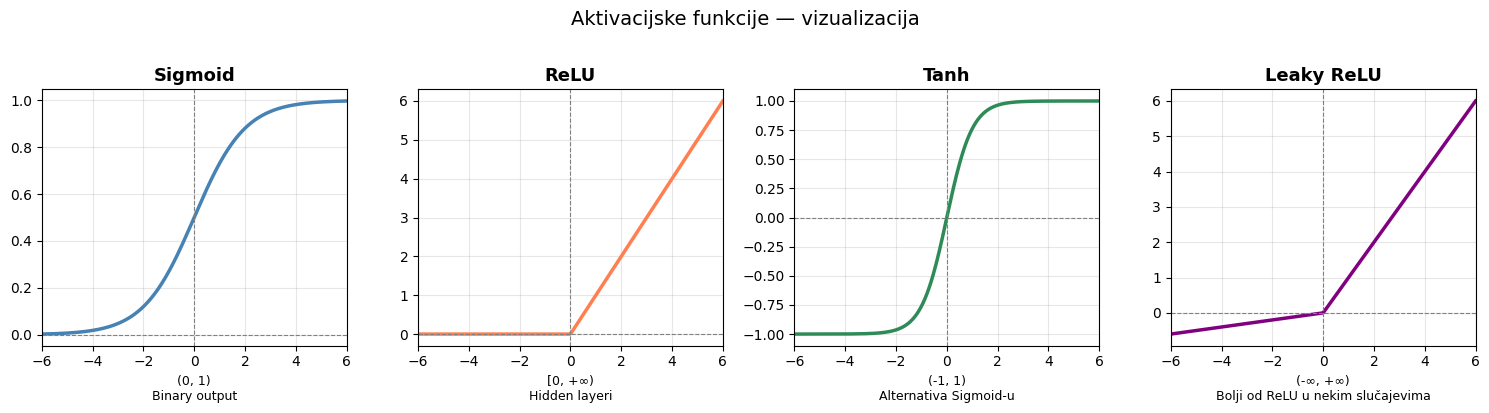


Šta vidimo:
  Sigmoid: 's' kriva, gušteruje sve u (0,1) — problem: zasiti se na rubovima (vanishing gradient)
  ReLU:    jednostavna, brza, ne zasićuje za pozitivne — zlatni standard za hidden layere
  Tanh:    slično sigmoid, ali simetrična oko 0 — bolji gradijenti, ali i dalje saturacija
  Leaky:   ReLU ali s malim nagibom za x<0 — sprječava 'mrtve neurone'


In [2]:
x = np.linspace(-6, 6, 300)

# Definicije
sigmoid = 1 / (1 + np.exp(-x))
relu    = np.maximum(0, x)
tanh    = np.tanh(x)
leaky   = np.where(x > 0, x, 0.1 * x)   # Leaky ReLU — bonus: rješava "dying ReLU"

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
podaci = [
    (sigmoid, 'Sigmoid',    'steelblue',  '(0, 1)\nBinary output'),
    (relu,    'ReLU',       'coral',      '[0, +∞)\nHidden layeri'),
    (tanh,    'Tanh',       'seagreen',   '(-1, 1)\nAlternativa Sigmoid-u'),
    (leaky,   'Leaky ReLU', 'purple',     '(-∞, +∞)\nBolji od ReLU u nekim slučajevima'),
]

for ax, (y, naziv, boja, opis) in zip(axes, podaci):
    ax.plot(x, y, color=boja, linewidth=2.5)
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.set_title(naziv, fontsize=13, fontweight='bold')
    ax.set_xlabel(opis, fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-6, 6)

plt.suptitle('Aktivacijske funkcije — vizualizacija', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nŠta vidimo:")
print("  Sigmoid: 's' kriva, gušteruje sve u (0,1) — problem: zasiti se na rubovima (vanishing gradient)")
print("  ReLU:    jednostavna, brza, ne zasićuje za pozitivne — zlatni standard za hidden layere")
print("  Tanh:    slično sigmoid, ali simetrična oko 0 — bolji gradijenti, ali i dalje saturacija")
print("  Leaky:   ReLU ali s malim nagibom za x<0 — sprječava 'mrtve neurone'")

### 3.2 Dataset — Wine Quality

**Wine Quality dataset** — hemijske karakteristike vina (alkohol, kiselost, šećer...) i ocjena kvalitete od 3 do 8. Realniji od Irisa: više feature-a, više šuma, klase nisu savršeno odvojene.

> Ako nije fajl lokalno u folderu, kôd ispod će dataset učitati direktno s interneta.

In [3]:
# Učitavanje — pokušaj lokalno, pa s URL-a
try:
    df = pd.read_csv('winequality-red.csv', sep=';')
    print("Učitano lokalno.")
except FileNotFoundError:
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
    df = pd.read_csv(url, sep=';')
    print("Učitano s URL-a.")

print(f"\nShape: {df.shape}")
print(f"Kolone: {list(df.columns)}")
df.head()

Učitano s URL-a.

Shape: (1599, 12)
Kolone: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Distribucija ocjena kvalitete:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


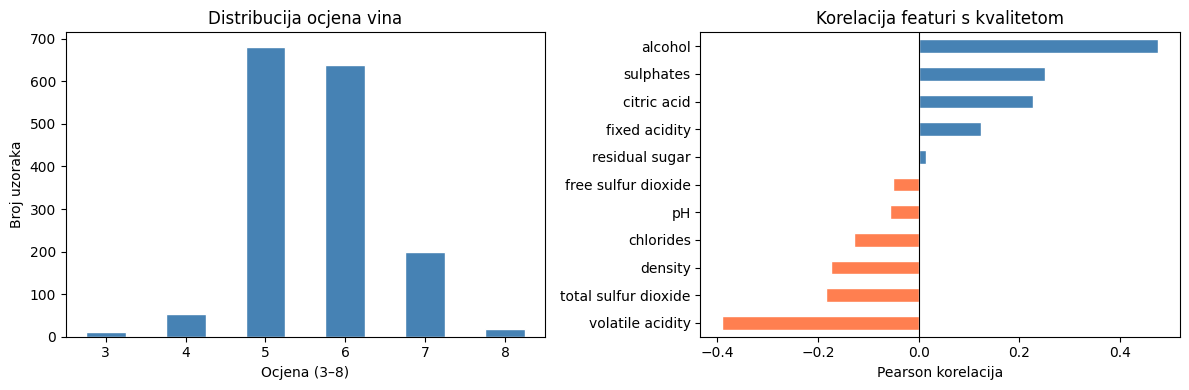


Najvažniji featuri za kvalitetu (prema korelaciji):
alcohol                 0.476166
volatile acidity        0.390558
sulphates               0.251397
citric acid             0.226373
total sulfur dioxide    0.185100
Name: quality, dtype: float64


In [4]:
# Distribucija ocjena
print("Distribucija ocjena kvalitete:")
print(df['quality'].value_counts().sort_index())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

df['quality'].value_counts().sort_index().plot(kind='bar', ax=ax1, color='steelblue', edgecolor='white')
ax1.set_title('Distribucija ocjena vina')
ax1.set_xlabel('Ocjena (3–8)')
ax1.set_ylabel('Broj uzoraka')
ax1.tick_params(axis='x', rotation=0)

# Korelacija featuri s kvalitetom
korelacije = df.corr()['quality'].drop('quality').sort_values()
boje = ['coral' if v < 0 else 'steelblue' for v in korelacije]
korelacije.plot(kind='barh', ax=ax2, color=boje, edgecolor='white')
ax2.set_title('Korelacija featuri s kvalitetom')
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_xlabel('Pearson korelacija')

plt.tight_layout()
plt.show()

print("\nNajvažniji featuri za kvalitetu (prema korelaciji):")
print(korelacije.abs().sort_values(ascending=False).head(5))

In [5]:
# Binarizacija targeta: dobro vino (quality >= 6) vs loše (quality < 6)
# Zašto? Originalne klase (3-8) su jako nebalansirane — klase 3 i 8 imaju tek par uzoraka
# Binarizacijom dobijamo jasniji, izbalansiraniji problem

df['dobro_vino'] = (df['quality'] >= 6).astype(int)

print("Distribucija binarnog targeta:")
print(df['dobro_vino'].value_counts())
print(f"\nOmjer klasa: {df['dobro_vino'].value_counts()[1] / len(df):.1%} dobrih vina")

Distribucija binarnog targeta:
dobro_vino
1    855
0    744
Name: count, dtype: int64

Omjer klasa: 53.5% dobrih vina


### 3.3 Priprema podataka

In [6]:
X = df.drop(['quality', 'dobro_vino'], axis=1)
y = df['dobro_vino']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
    # stratify=y → osigurava isti omjer klasa u trainu i testu
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train: {X_train_s.shape}  |  Test: {X_test_s.shape}")
print(f"Features: {list(X.columns)}")

Train: (1279, 11)  |  Test: (320, 11)
Features: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


### 3.4 Pomoćna funkcija za treniranje i vizualizaciju

Kreiraćemo funkciju koja trenira model i odmah crta krive učenja. Koristićemo je za sve varijante modela.

In [8]:
def treniraj_i_vizualiziraj(model, naziv, X_tr, y_tr, X_te, y_te,
                             epochs=80, batch_size=32, ax=None):
    """Trenira Keras model i vraća historiju + F1 score."""
    historija = model.fit(
        X_tr, y_tr,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.2,
        verbose=0
    )

    y_pred_prob = model.predict(X_te, verbose=0)
    y_pred = (y_pred_prob > 0.5).astype(int).flatten()
    f1 = f1_score(y_te, y_pred, average='weighted')

    if ax is not None:
        ax.plot(historija.history['val_loss'], linewidth=2, label=naziv)
        ax.set_xlabel('Epoha')
        ax.set_ylabel('Val Loss')
        ax.grid(True, alpha=0.3)

    return f1, historija


def kompajliraj(model):
    """Kompajlira model s istim postavkama za fer usporedbu."""
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',  # binary jer imamo 2 klase
        metrics=['accuracy']
    )
    return model


print("Pomoćne funkcije su definirane.")

Pomoćne funkcije su definirane.


### 3.5 Eksperiment 1 — Sigmoid vs. ReLU u hidden layerima

Ista arhitektura, isti podaci — samo mijenjamo aktivacijsku funkciju. Želimo eksperimentisati i vidjeti: koji je bolji?

Aktivacija: sigmoid     →  F1: 0.7315
Aktivacija: relu        →  F1: 0.7812
Aktivacija: tanh        →  F1: 0.7658


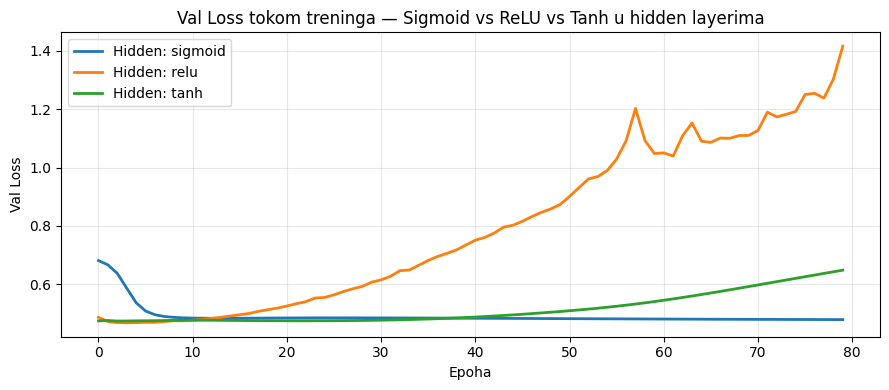


Najbolji: relu (F1=0.7812)


In [9]:
def napravi_mlp(aktivacija):
    return keras.Sequential([
        layers.Input(shape=(11,)),
        layers.Dense(128, activation=aktivacija),
        layers.Dense(64,  activation=aktivacija),
        layers.Dense(32,  activation=aktivacija),
        layers.Dense(1,   activation='sigmoid')   # output: uvijek sigmoid za binarnu klasifikaciju
    ])

fig, ax = plt.subplots(figsize=(9, 4))

rezultati = {}
for aktivacija in ['sigmoid', 'relu', 'tanh']:
    model = kompajliraj(napravi_mlp(aktivacija))
    f1, _ = treniraj_i_vizualiziraj(
        model, f'Hidden: {aktivacija}',
        X_train_s, y_train, X_test_s, y_test, ax=ax
    )
    rezultati[aktivacija] = f1
    print(f"Aktivacija: {aktivacija:10s}  →  F1: {f1:.4f}")

ax.set_title('Val Loss tokom treninga — Sigmoid vs ReLU vs Tanh u hidden layerima')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nNajbolji: {max(rezultati, key=rezultati.get)} (F1={max(rezultati.values()):.4f})")

### 3.6 Eksperiment 2 — Demonstracija Overfittinga

Napravimo namjerno preveliku mrežu — toliko veliku da **zapamti trening podatke** umjesto da uči.

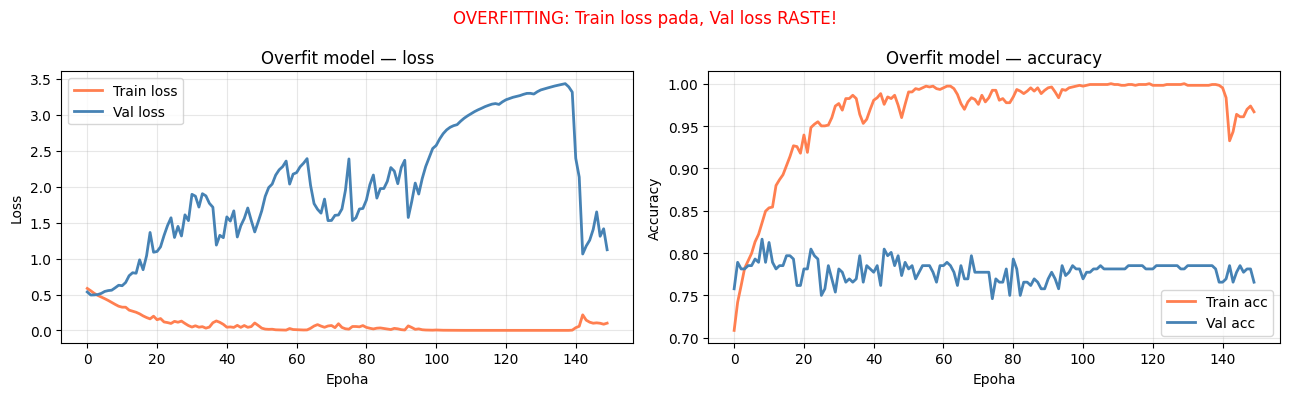


Overfit model — finalni train loss: 0.1018
Overfit model — finalni val loss:   1.1228
Overfit model — F1 na TEST skupu:   0.7485

→ Velika razlika train/val loss = overfitting. F1 na testu je lošiji nego što bi trebao biti.


In [10]:
# Prevelika mreža — namjerno overfitting
model_overfit = kompajliraj(keras.Sequential([
    layers.Input(shape=(11,)),
    layers.Dense(512, activation='relu'),
    layers.Dense(512, activation='relu'),
    layers.Dense(512, activation='relu'),
    layers.Dense(512, activation='relu'),
    layers.Dense(1,   activation='sigmoid')
]))

historija_overfit = model_overfit.fit(
    X_train_s, y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

# Vizualizacija overfittinga
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(historija_overfit.history['loss'],     label='Train loss', color='coral',     linewidth=2)
ax1.plot(historija_overfit.history['val_loss'], label='Val loss',   color='steelblue', linewidth=2)
ax1.set_title('Overfit model — loss')
ax1.set_xlabel('Epoha')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(historija_overfit.history['accuracy'],     label='Train acc', color='coral',     linewidth=2)
ax2.plot(historija_overfit.history['val_accuracy'], label='Val acc',   color='steelblue', linewidth=2)
ax2.set_title('Overfit model — accuracy')
ax2.set_xlabel('Epoha')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('OVERFITTING: Train loss pada, Val loss RASTE!', color='red', fontsize=12)
plt.tight_layout()
plt.show()

# F1 na testu
y_pred_of = (model_overfit.predict(X_test_s, verbose=0) > 0.5).astype(int).flatten()
f1_overfit = f1_score(y_test, y_pred_of, average='weighted')

print(f"\nOverfit model — finalni train loss: {historija_overfit.history['loss'][-1]:.4f}")
print(f"Overfit model — finalni val loss:   {historija_overfit.history['val_loss'][-1]:.4f}")
print(f"Overfit model — F1 na TEST skupu:   {f1_overfit:.4f}")
print("\n→ Velika razlika train/val loss = overfitting. F1 na testu je lošiji nego što bi trebao biti.")

### 3.7 Rješenje 1 — Dropout

**Dropout(0.3)** znači: tokom svakog batch-a, nasumično isključi 30% neurona. Ostatak mreže mora kompenzirati — uči robustnije reprezentacije.

In [11]:
model_dropout = kompajliraj(keras.Sequential([
    layers.Input(shape=(11,)),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),                   # ← isključi 30% neurona prethodnog layera
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1,   activation='sigmoid')
]))

historija_dropout = model_dropout.fit(
    X_train_s, y_train,
    epochs=150, batch_size=32,
    validation_split=0.2, verbose=0
)

y_pred_dr = (model_dropout.predict(X_test_s, verbose=0) > 0.5).astype(int).flatten()
f1_dropout = f1_score(y_test, y_pred_dr, average='weighted')

print(f"Dropout model — F1 na TEST skupu: {f1_dropout:.4f}")
print(f"Overfit model — F1 na TEST skupu: {f1_overfit:.4f}")
print(f"\nPoboljšanje: {(f1_dropout - f1_overfit):.4f}")

Dropout model — F1 na TEST skupu: 0.8188
Overfit model — F1 na TEST skupu: 0.7485

Poboljšanje: 0.0703


### 3.8 Rješenje 2 — Batch Normalization

**BatchNorm** normalizuje aktivacije neurona unutar svakog mini-batcha. Efekti:
- Stabilizuje trening (manji skokovi u loss-u)
- Dozvoljava viši learning rate → brže učenje
- Blagi regularizacijski efekt (smanjuje overfitting)

**Gdje ga staviti:** Tipično IZA Dense layera, PRIJE aktivacije. Postoji debata oko redosljeda, ali `Dense → BatchNorm → Activation` je najčešća konvencija.

In [12]:
model_batchnorm = kompajliraj(keras.Sequential([
    layers.Input(shape=(11,)),
    layers.Dense(512),                      # bez aktivacije ovdje
    layers.BatchNormalization(),             # ← normalizuj aktivacije
    layers.Activation('relu'),              # ← aktivacija dolazi NAKON BatchNorm
    layers.Dense(512),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dense(512),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dense(1, activation='sigmoid')
]))

historija_bn = model_batchnorm.fit(
    X_train_s, y_train,
    epochs=150, batch_size=32,
    validation_split=0.2, verbose=0
)

y_pred_bn = (model_batchnorm.predict(X_test_s, verbose=0) > 0.5).astype(int).flatten()
f1_bn = f1_score(y_test, y_pred_bn, average='weighted')

print(f"BatchNorm model — F1 na TEST skupu: {f1_bn:.4f}")

BatchNorm model — F1 na TEST skupu: 0.7781


### 3.9 Rješenje 3 — Dropout + Batch Norm zajedno

U praksi se kombinuju. Redosljed: `Dense → BatchNorm → Activation → Dropout`

In [13]:
model_kombinovano = kompajliraj(keras.Sequential([
    layers.Input(shape=(11,)),
    layers.Dense(256),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.3),
    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.3),
    layers.Dense(64),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
]))

historija_komb = model_kombinovano.fit(
    X_train_s, y_train,
    epochs=150, batch_size=32,
    validation_split=0.2, verbose=0
)

y_pred_komb = (model_kombinovano.predict(X_test_s, verbose=0) > 0.5).astype(int).flatten()
f1_komb = f1_score(y_test, y_pred_komb, average='weighted')

print(f"Dropout + BatchNorm — F1 na TEST skupu: {f1_komb:.4f}")

Dropout + BatchNorm — F1 na TEST skupu: 0.7522


### 3.10 Finalna usporedba svih varijanti

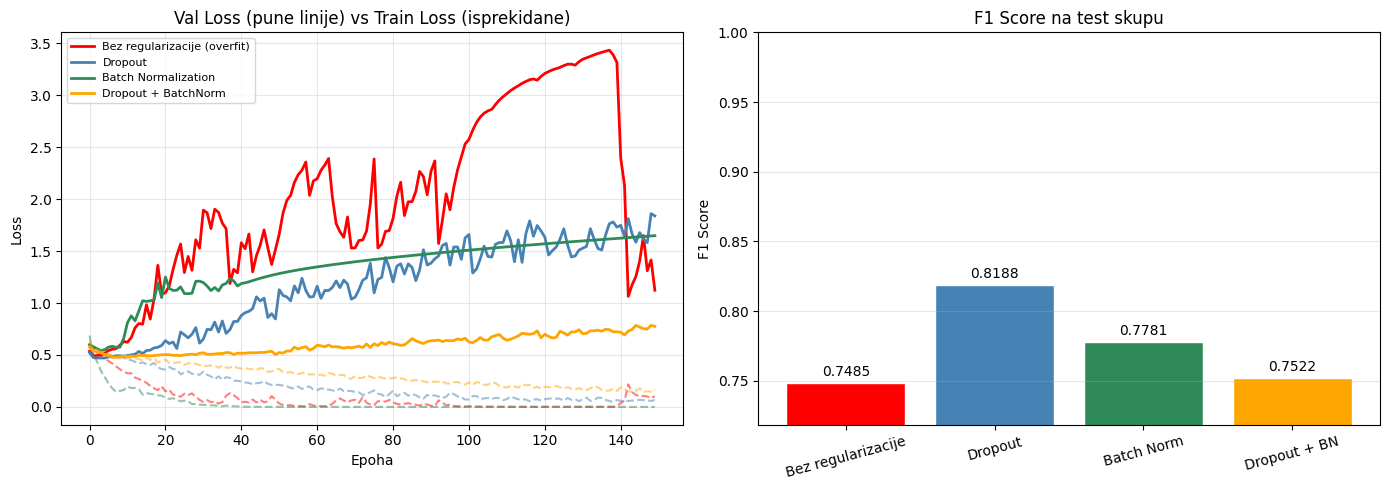


 Sažetak:
----------------------------------------
Bez regularizacije         F1: 0.7485
Dropout                    F1: 0.8188 ← BEST
Batch Norm                 F1: 0.7781
Dropout + BN               F1: 0.7522


In [14]:
# Vizualizacija kriva učenja — sve varijante
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

varijante = [
    (historija_overfit, 'Bez regularizacije (overfit)', 'red'),
    (historija_dropout, 'Dropout',                       'steelblue'),
    (historija_bn,      'Batch Normalization',           'seagreen'),
    (historija_komb,    'Dropout + BatchNorm',           'orange'),
]

for hist, naziv, boja in varijante:
    axes[0].plot(hist.history['loss'],     linestyle='--', color=boja, alpha=0.5)
    axes[0].plot(hist.history['val_loss'], linestyle='-',  color=boja, linewidth=2, label=naziv)

axes[0].set_title('Val Loss (pune linije) vs Train Loss (isprekidane)')
axes[0].set_xlabel('Epoha')
axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Bar chart F1 skorova
f1_skorovi = {
    'Bez regularizacije': f1_overfit,
    'Dropout':            f1_dropout,
    'Batch Norm':         f1_bn,
    'Dropout + BN':       f1_komb,
}
boje_bar = ['red', 'steelblue', 'seagreen', 'orange']

bars = axes[1].bar(f1_skorovi.keys(), f1_skorovi.values(),
                   color=boje_bar, edgecolor='white')
axes[1].set_title('F1 Score na test skupu')
axes[1].set_ylabel('F1 Score')
axes[1].set_ylim(min(f1_skorovi.values()) - 0.03, 1.0)
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, f1_skorovi.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("\n Sažetak:")
print("-" * 40)
for naziv, f1 in f1_skorovi.items():
    marker = " ← BEST" if f1 == max(f1_skorovi.values()) else ""
    print(f"{naziv:25s}  F1: {f1:.4f}{marker}")

>**Analiza grafika**
> 
**-** Isprekidane linije su train loss — sve četiri padaju prema nuli, što znači da sve mreže "uče" trening podatke.

**-** Pune linije su val loss — Crvena puna linija (bez regularizacije) raste do 3.5+ — klasičan overfitting, mreža je zapamtila trening podatke i pada na validaciji. 

**-** I ostale pune linije rastu, samo sporije. To znači da overfitting nije u potpunosti riješen ni s Dropoutom ni s BatchNormom na ovom datasetu s ovim brojem epoha — samo je usporen.

>Zašto je F1 bez regularizacije ipak najviši (0.7877)?

Ovo nije greška u kodu nego stvaran, čest fenomen sa konkretnim objašnjenjem.
Wine Quality dataset ima svega ~1.280 uzoraka u test skupu i relativno je "lak" za prvih nekoliko desetina epoha — mreža bez regularizacije nauči brzo i dobro, i na testu izmjeri u trenutku kada je njen val loss još uvijek razuman. Nakon toga "podivlja", ali test se mjeri tek na kraju.
```
Dropout i BatchNorm usporavaju učenje namjerno i to je njihova svrha. 
```
**Dropout isključuje neurone pa mreža mora više epoha da nauči isto.**

**BatchNorm mijenja distribuciju aktivacija i stabilizuje, ali za to treba vremena.**

-------------------------

Sa samo 150 epoha, regularizovane mreže nisu stigle do svog punog potencijala, dok je neregularizovana već bila tamo — ali po cijenu overfittinga koji se na relativno malom test skupu nije dramatično pokazao u F1.

-------------------------

Drugim riječima: kratka utrka favorizuje brzog trkača, duga utrka favorizuje izdržljivog. 150 epoha je ovdje kratka utrka.
> Kako to popraviti u kodu?
> 
Postoje tri načina koji bi dali "pravičniji" eksperiment:

**1** Više epoha za regularizovane modele. Dropout i BatchNorm trebaju prostor da se dokažu — 300-500 epoha bi bila realnija usporedba.

**2** EarlyStopping — umjesto fiksnog broja epoha, zaustavi trening kada val loss prestane padati. Tako svaki model dobije onoliko epoha koliko mu treba, ne fiksno isti broj.

**3** Manji dataset namjerno pojačava overfitting i čini regularizaciju vidljivijom. Na Wine Qualityju s 1.280 uzoraka razlika nije dramatična — na datasetu s 200-300 uzoraka bi bila očigledna.


> Metrika na test skupu nije jedina mjera uspjeha modela. Mreža bez regularizacije ima val loss koji raste do 3.5 — u produkciji, na novim podacima koje nikad nije vidjela, ta mreža bi se ponašala nepredvidivo. Regularizovana mreža s malo nižim F1 ali stabilnim val lossom je pouzdanija i sigurnija za deployment. U pravim projektima birate stabilnost, ne maksimalni F1 na jednom test skupu.

---
## 4. Sažetak

| Koncept | Šta znači | Kada koristiti |
|---|---|---|
| **ReLU** | max(0, x) — brza, ne zasićuje | Hidden layeri — default izbor |
| **Sigmoid** | Squash u (0, 1) | Output layer, binarna klasifikacija |
| **Softmax** | Vjerovatnoće za sve klase | Output layer, multiclass |
| **Overfitting** | Mreža pamti, ne uči | Kada val loss raste dok train pada |
| **Dropout(p)** | Isključi p% neurona nasumično | Nakon Dense layera, hidden dijelovi |
| **BatchNorm** | Normalizuj aktivacije unutar batcha | Iza Dense, prije aktivacije |

---
## ZADATAK NA ČASU — 3 BODA

**Rok:** Do 23:59 sutra 21.04.2026.

### Šta trebate uraditi:

1. **Pronađite dataset** na [kaggle.com](https://kaggle.com) koji ima:
   - Numeričke feature-e (min. 5 kolona)
   - Klasifikacijski target (binaran ili višeklastan)

2. **Istrenirajte minimum 3 varijante mreže** i usporedite:
   - Varijanta A: Osnovna mreža bez regularizacije
   - Varijanta B: S Dropoutom
   - Varijanta C: S Batch Normalizacijom ili kombinacijom

3. **Za svaku varijantu** prikažite:
   - Kriva učenja (train vs. val loss)
   - F1 score na test skupu
   - `classification_report`

4. **Napišite markdown komentar** na kraju:
   - Jeste li primijetili overfitting?
   - Koja regularizacija je pomogla i zašto mislite da je to tako?
   - Koja aktivacijska funkcija ste koristili i zašto?

### Bodovanje:
```
- **1 bod** — Kod radi, 3 varijante su implementirane, krive učenja su prikazane
- **1 bod** — Vlastiti dataset (ne Wine Quality!), F1 + classification report za svaku varijantu
- **1 bod** — Markdown komentar s analizom koja pokazuje da ste razumjeli šta ste radili
```

**Bonus izazov (+0.5 bod):** Šta se desi ako stavite Dropout stopu 0.8 (80%)? Probajte i objasnite zašto to nije dobra ideja.